# **TP2 Optimización**: Heurísticas

In [68]:
using Pkg
Pkg.add(["LinearAlgebra", "Plots", "Random", "DataFrames", "Statistics"])

   Resolving package versions...
    Updating `~/.julia/environments/v1.10/Project.toml`
  [10745b16] + Statistics v1.10.0
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [1]:
include("benchmarks.jl")
include("visualizaciones.jl")
using LinearAlgebra, Plots, Random, DataFrames, Statistics
using DataFrames: groupby, combine

In [2]:
function rangos_camino(path; margen=0.15, paso=0.05)
    xs_pts = [pt[1] for pt in path]
    ys_pts = [pt[2] for pt in path]

    xmin, xmax = extrema(xs_pts)
    ymin, ymax = extrema(ys_pts)

    dx = max(xmax - xmin, 1.0) * margen
    dy = max(ymax - ymin, 1.0) * margen

    xs = (xmin - dx):paso:(xmax + dx)
    ys = (ymin - dy):paso:(ymax + dy)
    return xs, ys
end

rangos_camino (generic function with 1 method)

## **1.** Heurísticas

### **Hill Climbing**

In [3]:
function hill_climbing_standard(f, x₀; σ=0.1, max_iter=10000, max_no_improve=100)
    # Inicialización
    best   = copy(x₀)
    f_best = f(best)
    camino = [copy(best)]
    n      = length(x₀)

    # Iteraciones
    iter = 0; no_improve = 0
    while iter < max_iter
        v  = best .+ σ .* randn(n)  
        fv = f(v)

        # Heurística
        if fv < f_best
            best, f_best = v, fv
            push!(camino, copy(best))
            iter += 1; no_improve = 0
        else
            no_improve += 1
            no_improve ≥ max_no_improve && break 
        end
    end

    return best, f_best, iter, camino
end

hill_climbing_standard (generic function with 1 method)

In [4]:
function hill_climbing_dinamic(f, x₀; σ=0.1, α=1.5, β=0.5, μ=20, max_iter=10000)
    # Inicialización
    best   = copy(x₀)
    f_best = f(best)
    camino = [copy(best)]
    n      = length(x₀)

    # Iteraciones
    iter = 0; no_improve = 0;
    while iter < max_iter && σ > 1e-8
        v  = best .+ σ .* randn(n)  
        fv = f(v)

        # Heurística
        if fv < f_best
            best, f_best, σ = v, fv, σ*α
            push!(camino, copy(best))
            iter += 1; no_improve = 0
        else
            no_improve += 1
            if no_improve ≥ μ
                σ = σ*β; no_improve = 0
            end
        end
    end

    return best, f_best, iter, camino
end

hill_climbing_dinamic (generic function with 1 method)

### **Recocido Simulado**

In [5]:
function simulated_annealing(f, x₀; T₀=10.0, a=0.99, σ=0.5, T_min=1e-8, max_iter=100000)
    # Inicialización
    x       = copy(x₀)
    fx      = f(x)
    best    = copy(x)
    f_best  = fx
    camino  = [copy(x)]
    n       = length(x₀)
    
    # Iteraciones
    T = T₀; iter = 0;
    while T > T_min && iter < max_iter
        v  = x .+ σ .* randn(n)
        fv = f(v)
        T  = a*T
        
        # Heurística
        if fv < fx
            x, fx = v, fv
            if fx < f_best
                best  = copy(x)
                f_best = fx
                push!(camino, copy(best))
            end
        elseif exp((fx - fv)/T) > rand()
            x, fx = v, fv
        end
        iter += 1
    end
    
    return best, f_best, iter, camino
end

simulated_annealing (generic function with 1 method)

## **2.** Testing

In [6]:
# Puntos iniciales
x0_2d = [1.0, 1.0]
x0_rb = [-1.2, 1.0]
x0_wd = [-3.0, -1.0, -3.0, -1.0]
x0_fr = [0.5, -2.0]

benchmarks = [
    ("Sphere",      sphere,      x0_2d),
    ("Rosenbrock",  rosenbrock,  x0_rb),
    ("Rastrigin",   rastrigin,   x0_2d),
    ("Wood",        wood,        x0_wd),
    ("Froth",       froth,       x0_fr),
]

metodos = [
    ("Hill Climbing",      (f, x0) -> hill_climbing_standard(f, x0; σ=0.1)),
    ("HC Dinámico",        (f, x0) -> hill_climbing_dinamic(f, x0; σ=0.1, α=1.5, β=0.5, μ=20)),
    ("Recocido Simulado",  (f, x0) -> simulated_annealing(f, x0; T₀=1000.0, a=0.999)),
]

3-element Vector{Tuple{String, Function}}:
 ("Hill Climbing", var"#15#18"())
 ("HC Dinámico", var"#16#19"())
 ("Recocido Simulado", var"#17#20"())

In [7]:
Random.seed!(912)     # Seed
N = 100               # Corridas por método y función

resultados = DataFrame(
    Funcion = String[],
    Metodo  = String[],
    fBest   = Float64[],
    Pasos   = Int[],
    xFinal  = Vector{Float64}[],
)

for (nombre, f, x0) in benchmarks
    for (nombre_met, metodo) in metodos
        print("Ejecutando $nombre_met en $nombre... ")
        for _ in 1:N
            best, f_best, iter, _ = metodo(f, x0)
            push!(resultados, (nombre, nombre_met, f_best, iter, best))
        end
        println("$N corridas listas")
    end
end

Ejecutando Hill Climbing en Sphere... 100 corridas listas
Ejecutando HC Dinámico en Sphere... 100 corridas listas
Ejecutando Recocido Simulado en Sphere... 100 corridas listas
Ejecutando Hill Climbing en Rosenbrock... 100 corridas listas
Ejecutando HC Dinámico en Rosenbrock... 100 corridas listas
Ejecutando Recocido Simulado en Rosenbrock... 100 corridas listas
Ejecutando Hill Climbing en Rastrigin... 100 corridas listas
Ejecutando HC Dinámico en Rastrigin... 100 corridas listas
Ejecutando Recocido Simulado en Rastrigin... 100 corridas listas
Ejecutando Hill Climbing en Wood... 100 corridas listas
Ejecutando HC Dinámico en Wood... 100 corridas listas
Ejecutando Recocido Simulado en Wood... 100 corridas listas
Ejecutando Hill Climbing en Froth... 100 corridas listas
Ejecutando HC Dinámico en Froth... 100 corridas listas
Ejecutando Recocido Simulado en Froth... 100 corridas listas


In [8]:
resumen = combine(groupby(resultados, [:Funcion, :Metodo]),
    :fBest => minimum  => :fBest_min,
    :fBest => mean     => :fBest_med,
    :fBest => std      => :fBest_std,
    :Pasos => mean     => :Pasos_med,
)

# Redondeo 
for col in [:fBest_min, :fBest_med, :fBest_std, :Pasos_med]
    resumen[!, col] = round.(resumen[!, col], digits=4)
end
resumen

Row,Funcion,Metodo,fBest_min,fBest_med,fBest_std,Pasos_med
,String,String,Float64,Float64,Float64,Float64
1,Sphere,Hill Climbing,0.0,0.0002,0.0002,22.0
2,Sphere,HC Dinámico,0.0,0.0,0.0,42.06
3,Sphere,Recocido Simulado,0.0,0.0,0.0,25316.0
4,Rosenbrock,Hill Climbing,0.0,0.1022,0.584,38.08
5,Rosenbrock,HC Dinámico,0.0,0.0,0.0,171.31
6,Rosenbrock,Recocido Simulado,0.0,0.0004,0.0004,25316.0
7,Rastrigin,Hill Climbing,1.99,1.9991,0.0022,0.23
8,Rastrigin,HC Dinámico,1.9899,1.9899,0.0,28.05
9,Rastrigin,Recocido Simulado,0.0,0.0045,0.0049,25316.0


→ Sphere / Hill Climbing


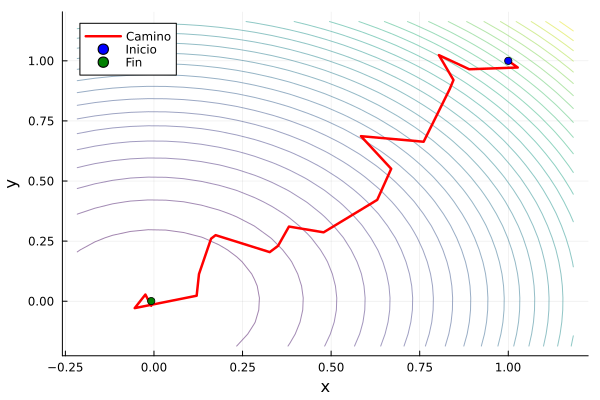

→ Sphere / HC Dinámico


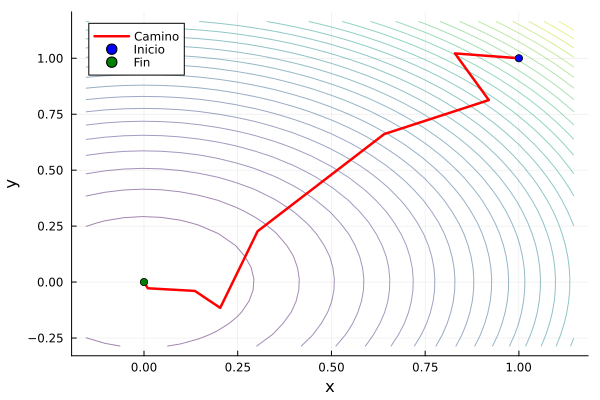

→ Sphere / Recocido


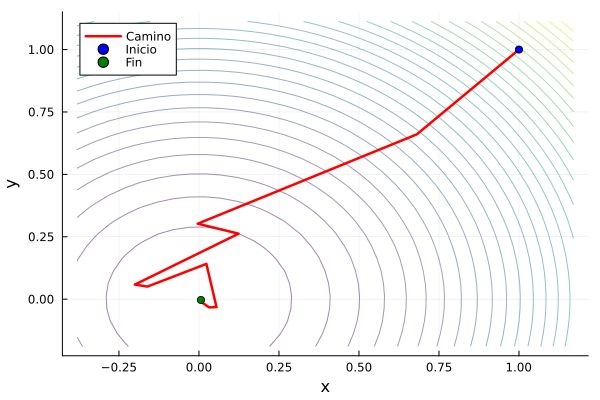

→ Rastrigin / Hill Climbing


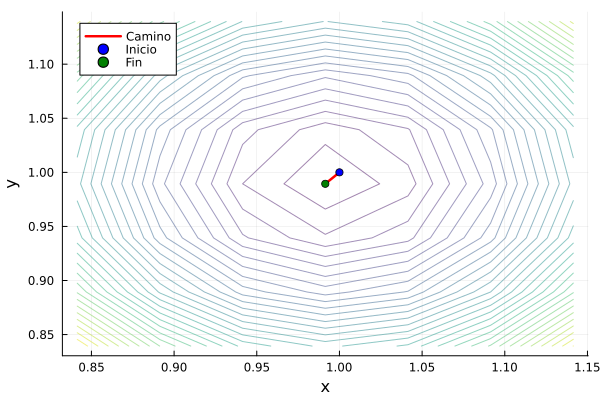

→ Rastrigin / HC Dinámico


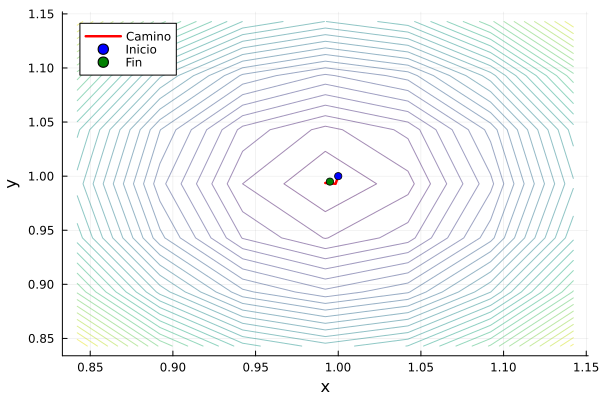

→ Rastrigin / Recocido


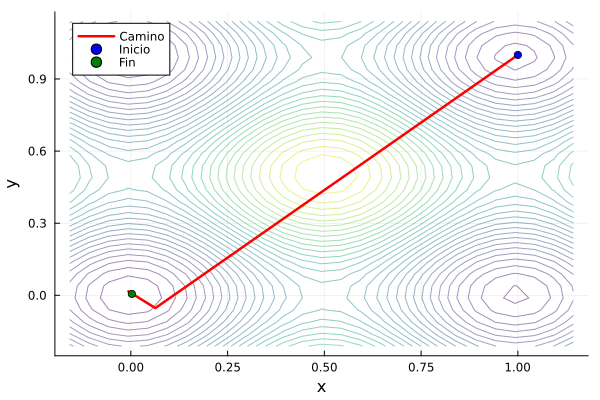

→ Froth / Hill Climbing


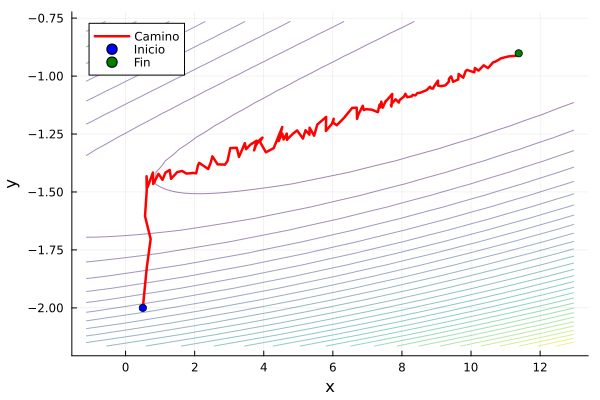

→ Froth / HC Dinámico


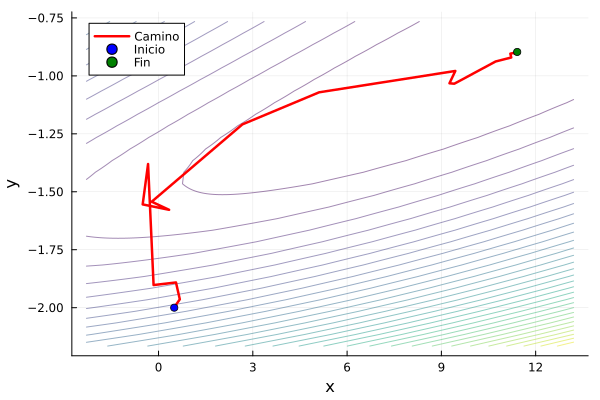

→ Froth / Recocido


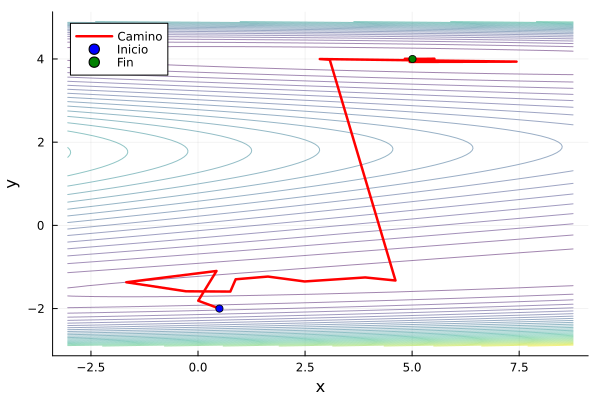

In [24]:
configs = [
    ("Sphere",    sphere,    [1.0, 1.0]),
    ("Rastrigin", rastrigin, [1.0, 1.0]),
    ("Froth",     froth,     [0.5, -2.0]),
]

for (nombre, f, x0) in configs
    _, _, _, cam_hc  = hill_climbing_standard(f, x0; σ=0.1)
    _, _, _, cam_din = hill_climbing_dinamic(f, x0; σ=0.1, α=1.5, β=0.5, μ=20)
    _, _, _, cam_sa  = simulated_annealing(f, x0; T₀=1000.0, a=0.999)

    for (met, cam) in [("Hill Climbing", cam_hc), ("HC Dinámico", cam_din), ("Recocido", cam_sa)]
        println("→ $nombre / $met")
        xs, ys = rangos_camino(cam)        # dominio auto-ajustado a cada camino
        visualizar_camino(f, cam, xs, ys)
    end
end

## **3.** Conclusiones

En las funciones convexas (Sphere y Rosenbrock) los tres métodos alcanzan el mínimo global (`fBest_min = 0` en todos los casos). Aquí no hay mínimos locales donde quedar atrapado, de modo que la búsqueda local es suficiente. La única diferencia relevante es el costo: sobre Sphere, el Hill Climbing converge en unos 22 pasos, frente a los ~25.300 del Recocido Simulado.

En las funciones con mínimos locales marcados (Rastrigin y Froth) aparece la diferencia central del trabajo. Ambas variantes de Hill Climbing quedan sistemáticamente atrapadas:

- En Rastrigin, partiendo de `(1,1)`, los dos Hill Climbing convergen siempre al pozo local cercano (`fBest ≈ 1.99`, con desvío casi nulo), sin acercarse al mínimo global en `(0,0)`. El Recocido Simulado, en cambio, alcanza el global en la práctica totalidad de las corridas (`fBest_med ≈ 0.0045`).
- En Froth, partiendo de `(0.5,-2)`, el Hill Climbing estándar cae siempre en el mínimo local `≈(11.41, -0.897)` con `f ≈ 48.98` (media 49.09, desvío 0.54: consistente pero incapaz de escapar). El Recocido Simulado logra el global con frecuencia apreciable (`fBest_med ≈ 12.26`), y el Hill Climbing dinámico lo alcanza solo ocasionalmente (`fBest_min = 0` pero media 40.66).

Los resultados evidencian las diferencias entre **exploración y explotación**. El Hill Climbing explota de forma agresiva y económica, pero es incapaz de escapar de óptimos locales, lo que lo vuelve confiable solo en buenas condiciones. El Recocido Simulado sacrifica velocidad y consistencia a cambio de una capacidad de exploración global que lo hace claramente superior en las funciones multimodales.

En términos prácticos: no existe un método uniformemente mejor. La elección depende de la estructura del problema. Si se sabe que la función es convexa, el Hill Climbing (preferentemente dinámico, por su eficiencia) puede ser una buen elección. Si se desconce la estrucutra de la función, y encontrar el óptimo global es prioritario, el Recocido Simulado justifica su mayor costo computacional.